# Day 7: Model Comparison

## Objective

Compare multiple text-classification algorithms using the same training data
and TF-IDF configuration.

Models:

- Balanced Logistic Regression
- Linear Support Vector Classification
- Complement Naive Bayes

The primary comparison metric is macro F1 because the dataset classes are
imbalanced. Cross-validation will be performed on the training set before the
selected model is evaluated on the test set.

In [3]:
#Load the data and recreate the split

from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

project_root = Path.cwd().parent
data_path = project_root / "data" / "processed" / "cleaned_tickets.csv"

df = pd.read_csv(data_path)

X = df["ticket_text"]
y = df["queue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset shape:", df.shape)
print("Training tickets:", len(X_train))
print("Test tickets:", len(X_test))

Dataset shape: (11814, 2)
Training tickets: 9451
Test tickets: 2363


In [4]:
#stratified 5-fold cross-validation

from sklearn.model_selection import StratifiedKFold

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Number of folds:", cross_validation.get_n_splits())

Number of folds: 5


### Defining the three model pipelines
For a fair comparison, every model must receive text processed with the same TF-IDF settings. Each pipeline contains:
1. A new TF-IDF vectorizer
2. One classification algorithm

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB

models = {
    "Balanced Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=5000,
            ngram_range=(1, 2)
        )),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=5000,
            ngram_range=(1, 2)
        )),
        ("classifier", LinearSVC(
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Complement Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            max_features=5000,
            ngram_range=(1, 2)
        )),
        ("classifier", ComplementNB())
    ])
}

print("Models ready:")
for model_name in models:
    print("-", model_name)

Models ready:
- Balanced Logistic Regression
- Linear SVM
- Complement Naive Bayes


In [7]:
from sklearn.model_selection import cross_val_score

cv_results = []

for model_name, pipeline in models.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cross_validation,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_results.append({
        "model": model_name,
        "mean_macro_f1": scores.mean(),
        "std_macro_f1": scores.std()
    })

    print(model_name)
    print("Fold scores:", scores)
    print(f"Mean macro F1: {scores.mean():.4f}")
    print()

Balanced Logistic Regression
Fold scores: [0.60629912 0.61905236 0.60523119 0.62073508 0.61424496]
Mean macro F1: 0.6131

Linear SVM
Fold scores: [0.63556583 0.64633398 0.64194935 0.66431043 0.65513064]
Mean macro F1: 0.6487

Complement Naive Bayes
Fold scores: [0.54993756 0.52938956 0.55241187 0.53596214 0.52848871]
Mean macro F1: 0.5392



In [8]:
cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("mean_macro_f1", ascending=False)
    .reset_index(drop=True)
)

cv_results_df

,model,mean_macro_f1,std_macro_f1
0,Linear SVM,0.648658,0.010087
1,Balanced Logistic Regression,0.613113,0.006375
2,Complement Naive Bayes,0.539238,0.010112


In [9]:
#Training Linear SVM on the full training set

from sklearn.metrics import accuracy_score, classification_report

final_svm_model = models["Linear SVM"]
final_svm_model.fit(X_train, y_train)

svm_predictions = final_svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"Linear SVM test accuracy: {svm_accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))

Linear SVM test accuracy: 66.69%

Classification Report:
                      precision    recall  f1-score   support

Billing and Payments       0.78      0.82      0.80       319
    Customer Service       0.54      0.60      0.57       482
     Product Support       0.61      0.55      0.58       615
   Technical Support       0.73      0.73      0.73       947

            accuracy                           0.67      2363
           macro avg       0.67      0.67      0.67      2363
        weighted avg       0.67      0.67      0.67      2363



## Linear SVM Test Results

Linear SVM achieved:

- Test accuracy: 66.69%
- Macro F1: 0.67
- Weighted F1: 0.67

Compared with balanced Logistic Regression:

- Accuracy improved from 61.66% to 66.69%.
- Macro F1 improved from 0.62 to 0.67.
- F1-score improved for all four ticket categories.
- Product Support improved from 0.52 to 0.58 F1.
- Customer Service improved from 0.52 to 0.57 F1.
- Technical Support improved from 0.68 to 0.73 F1.
- Billing and Payments improved from 0.78 to 0.80 F1.

Linear SVM is the strongest classification candidate so far. However,
`LinearSVC` does not directly provide probability estimates, so it cannot yet
replace the saved Logistic Regression pipeline used for confidence-based
manual review.

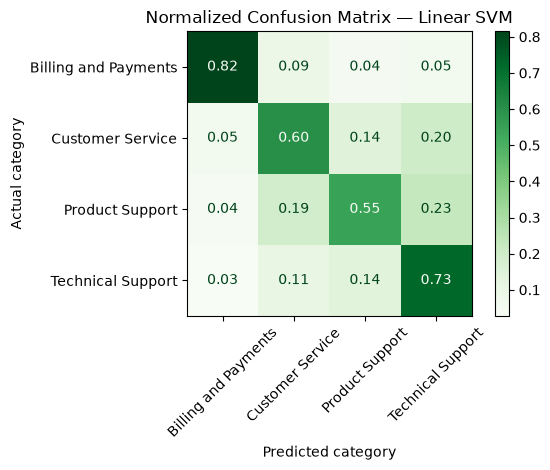

In [13]:
#The SVM confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions,
    labels=final_svm_model.classes_,
    normalize="true",
    cmap="Greens",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix — Linear SVM")
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.tight_layout()
plt.show()

## Linear SVM Confusion Matrix Findings

Compared with balanced Logistic Regression, Linear SVM improved recall for
all four categories:

- Billing and Payments: 79% to 82%
- Customer Service: 57% to 60%
- Product Support: 49% to 55%
- Technical Support: 67% to 73%

The largest recall improvements occurred for Product Support and Technical
Support, with gains of approximately six percentage points each.

Linear SVM reduces classification errors across all categories and is the
strongest model tested so far.

In [15]:
#Saving the SVM as a candidate model

import joblib

svm_model_path = project_root / "models" / "linear_svm_pipeline.joblib"

joblib.dump(final_svm_model, svm_model_path)

print("SVM model saved to:", svm_model_path)
print("File exists:", svm_model_path.exists())

SVM model saved to: /Users/yogithagujjarlapudi/AI-ML Course/AI-ML-PROJECTS/AI-ML/Customer-Support-Ticket-Intelligence/models/linear_svm_pipeline.joblib
File exists: True


In [16]:
#verifying

loaded_svm = joblib.load(svm_model_path)

loaded_svm_predictions = loaded_svm.predict(X_test)

print(
    "Reloaded model predictions match:",
    (loaded_svm_predictions == svm_predictions).all()
)

Reloaded model predictions match: True


### Model Comparison

- Compared balanced Logistic Regression, Linear SVM, and Complement Naive
  Bayes using five-fold stratified cross-validation.
- Used macro F1 as the primary metric because the classes are imbalanced.
- Linear SVM achieved the best mean cross-validation macro F1 at 0.6487.
- Balanced Logistic Regression achieved 0.6131.
- Complement Naive Bayes achieved 0.5392.
- Linear SVM achieved 66.69% test accuracy and 0.67 macro F1.
- Linear SVM improved F1-score for all four ticket categories.
- Saved Linear SVM locally as a candidate model.
- Kept Logistic Regression as the current deployable model because Linear SVM
  requires probability calibration before supporting confidence-based review.